# 멋진 챗봇 만들기

- Tesla T4와 PyTorch CUDA GPU 사용
- 검증 손실 증가를 줄이기 위한 AdamW, Weight Decay, Dropout 강화
- Boolean Causal Mask로 PyTorch 마스크 경고 제거
- 너무 희귀한 단어를 과도하게 밀어주던 기존 보정값 축소
- 반복 단어 페널티, 특수 토큰 차단, 최소 생성 길이 적용
- No-repeat 3-gram과 Top-k + Top-p Sampling 적용
- 고유 답변 비율 외에 Distinct-1, Distinct-2도 계산
- 최적 모델 체크포인트 자동 저장


In [ ]:
# ============================================================
# 0. 환경 설정 — Jupyter GPU / PyTorch 버전
# ============================================================
# TensorFlow는 설치하거나 삭제하지 않습니다.
# 현재 Jupyter 커널에 이미 설치된 CUDA 지원 PyTorch를 그대로 사용합니다.
%pip install -q pandas numpy scikit-learn nltk gensim matplotlib konlpy JPype1 python-mecab-ko

import os
import re
import sys
import math
import time
import random
import urllib.request
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import sklearn
import gensim
import nltk
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 재현성과 속도의 균형을 위한 설정
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if DEVICE.type != "cuda":
    raise RuntimeError(
        "GPU가 인식되지 않았습니다. 먼저 !nvidia-smi와 "
        "torch.cuda.is_available() 결과를 확인하세요."
    )

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())
print("사용 장치:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))
print("GPU 메모리:",
      round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), "GB")


class SimpleTokenizer:
    """TensorFlow/Keras 없이 사용하는 간단한 단어 사전 클래스입니다."""
    def __init__(self, oov_token="<unk>"):
        self.oov_token = oov_token
        self.word_index = {}
        self.index_word = {}

    def fit_on_texts(self, texts):
        """
        토큰화된 전체 문장을 이용해 vocabulary를 구축합니다.
        0번 인덱스는 Padding을 위해 비워 둡니다.
        """
        counts = Counter(token for text in texts for token in text)
        # 0번은 padding으로 비워 둡니다.
        words = [self.oov_token] + [
            word for word, _ in counts.most_common()
            if word != self.oov_token
        ]
        self.word_index = {word: i + 1 for i, word in enumerate(words)}
        self.index_word = {i: word for word, i in self.word_index.items()}

    def texts_to_sequences(self, texts):
        """
        토큰 문장을 정수 인덱스 시퀀스로 변환합니다.
        사전에 없는 토큰은 <unk> 인덱스로 대체합니다.
        """
        unk_id = self.word_index[self.oov_token]
        return [
            [self.word_index.get(token, unk_id) for token in text]
            for text in texts
        ]


def pad_sequences(sequences, maxlen, padding="post", truncating="post", value=0):
    """
    길이가 다른 정수 시퀀스를 maxlen 길이로 Padding 또는 Truncation합니다.
    반환값은 모델 입력에 사용할 2차원 NumPy 배열입니다.
    """
    result = np.full((len(sequences), maxlen), value, dtype=np.int64)
    for i, seq in enumerate(sequences):
        seq = list(seq)
        if len(seq) > maxlen:
            seq = seq[:maxlen] if truncating == "post" else seq[-maxlen:]
        if padding == "post":
            result[i, :len(seq)] = seq
        else:
            result[i, -len(seq):] = seq
    return result


def _load_tokenizer():
    """사용 가능한 한국어 형태소 분석기를 순서대로 시도합니다."""
    try:
        from konlpy.tag import Mecab
        m = Mecab()
        print("KoNLPy Mecab 사용")
        return m.morphs
    except Exception as e:
        print("KoNLPy Mecab 로드 실패:", e)

    try:
        from mecab import MeCab as PyMecabKo
        m = PyMecabKo()
        print("python-mecab-ko 사용")
        return m.morphs
    except Exception as e:
        print("python-mecab-ko 로드 실패:", e)

    try:
        from konlpy.tag import Okt
        okt = Okt()
        print("Mecab 대신 Okt를 사용합니다.")
        return okt.morphs
    except Exception as e:
        print("Okt 로드 실패:", e)

    print("형태소 분석기를 사용할 수 없어 공백 토큰화를 사용합니다.")
    return lambda text: text.split()


tokenize_fn = _load_tokenizer()
print("Mecab 테스트:", tokenize_fn("안녕하세요. 챗봇 프로젝트입니다."))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.6/579.6 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 15.6 MB/s eta 0:00:00
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
CUDA 사용 가능: True
사용 장치: cuda:0
GPU: Tesla T4
GPU 메모리: 14.6 GB
KoNLPy Mecab 로드 실패: Install MeCab in order to use it: http://konlpy.org/en/latest/install/
python-mecab-ko 사용
Mecab 테스트: ['안녕', '하', '세요', '.', '챗', '봇', '프로젝트', '입니다', '.']


## Step 1. 데이터와 `ko.bin` 준비


In [ ]:
# Step 1. ChatbotData.csv를 로드하고 데이터 경로를 준비합니다.
# 데이터가 없으면 자동 다운로드를 시도합니다.
DATA_DIR = os.path.join(os.path.expanduser("~"), "aiffel", "transformer_chatbot", "data")
os.makedirs(DATA_DIR, exist_ok=True)

CSV_PATH = Path(DATA_DIR) / "ChatbotData.csv"
CSV_URL = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"

if not CSV_PATH.exists():
    print("ChatbotData.csv가 없어 GitHub에서 다운로드합니다...")
    urllib.request.urlretrieve(CSV_URL, CSV_PATH)

# ko.bin을 여러 후보 경로에서 찾습니다 (노트북과 같은 폴더에 두는 경우도 지원).
WORD2VEC_CANDIDATES = [
    Path(DATA_DIR) / "ko" / "ko.bin",
    Path(DATA_DIR) / "ko.bin",
    Path(os.getcwd()) / "ko.bin",
]
WORD2VEC_PATH = next((p for p in WORD2VEC_CANDIDATES if p.exists()), None)

if WORD2VEC_PATH is None:
    raise FileNotFoundError(
        "ko.bin을 찾을 수 없습니다. 다음 경로 중 하나에 파일을 놓아주세요:\n"
        + "\n".join(str(p) for p in WORD2VEC_CANDIDATES)
    )

print("CSV:", CSV_PATH)
print("ko.bin:", WORD2VEC_PATH)


ChatbotData.csv가 없어 GitHub에서 다운로드합니다...
CSV: /root/aiffel/transformer_chatbot/data/ChatbotData.csv
ko.bin: /content/ko.bin


In [ ]:
# Step 2. 원본 질문(Q)과 답변(A)을 불러오고 기본 통계를 확인합니다.
data = pd.read_csv(CSV_PATH)

if not {"Q", "A"}.issubset(data.columns):
    raise ValueError(
        f"CSV에 Q, A 컬럼이 필요합니다. 현재 컬럼: {list(data.columns)}"
    )

questions = data["Q"].astype(str).tolist()
answers = data["A"].astype(str).tolist()

print("전체 데이터 수:", len(data))
display(data.head())


전체 데이터 수: 11823


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


## Step 2~3. 데이터 정제 및 Mecab 토큰화


In [ ]:
# Step 3. 문장 정제 및 형태소 토큰화를 수행합니다.
# 특수문자를 제거하고 모델 학습용 토큰 시퀀스를 생성합니다.
def preprocess_sentence(sentence):
    """영문 소문자화 및 허용 문자만 남기는 정제 함수입니다."""
    sentence = str(sentence).lower().strip()
    sentence = re.sub(r"[^0-9a-zA-Z가-힣ㄱ-ㅎㅏ-ㅣ.,?!]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence


MAX_TOKEN_LENGTH = 40


def build_corpus(src_sentences, tgt_sentences, tokenizer_func, max_len=40):
    """정제·토큰화·길이 필터링·중복 제거를 수행합니다."""
    src_corpus = []
    tgt_corpus = []

    seen_src = set()
    seen_tgt = set()

    removed_long = 0
    removed_duplicate = 0
    removed_empty = 0

    for src, tgt in zip(src_sentences, tgt_sentences):
        src_clean = preprocess_sentence(src)
        tgt_clean = preprocess_sentence(tgt)

        if not src_clean or not tgt_clean:
            removed_empty += 1
            continue

        src_tokens = tokenizer_func(src_clean)
        tgt_tokens = tokenizer_func(tgt_clean)

        if not src_tokens or not tgt_tokens:
            removed_empty += 1
            continue

        # 과제 문구의 '일정 길이 이상 제외'를 반영합니다.
        if len(src_tokens) >= max_len or len(tgt_tokens) >= max_len:
            removed_long += 1
            continue

        # 소스는 소스대로, 타겟은 타겟대로 중복 검사합니다.
        if src_clean in seen_src or tgt_clean in seen_tgt:
            removed_duplicate += 1
            continue

        seen_src.add(src_clean)
        seen_tgt.add(tgt_clean)

        src_corpus.append(src_tokens)
        tgt_corpus.append(tgt_tokens)

    print("원본 데이터 수:", len(src_sentences))
    print("최종 corpus 수:", len(src_corpus))
    print("길이 초과 제거:", removed_long)
    print("중복 제거:", removed_duplicate)
    print("빈 문장 제거:", removed_empty)

    return src_corpus, tgt_corpus


que_corpus, ans_corpus = build_corpus(
    questions,
    answers,
    tokenizer_func=tokenize_fn,
    max_len=MAX_TOKEN_LENGTH,
)

assert len(que_corpus) == len(ans_corpus)
assert len(que_corpus) > 0

print("질문 예시:", que_corpus[0])
print("답변 예시:", ans_corpus[0])


원본 데이터 수: 11823
최종 corpus 수: 7738
길이 초과 제거: 1
중복 제거: 4084
빈 문장 제거: 0
질문 예시: ['12', '시', '땡', '!']
답변 예시: ['하루', '가', '또', '가', '네요', '.']


### 응답 붕괴 진단: 답변 쏠림 확인

챗봇이 아무 질문에나 비슷한 답변만 내놓는 응답 붕괴는, 대개 **학습 데이터에서 몇몇 답변이
지나치게 자주 등장**하기 때문에 생깁니다. MLE로 학습하는 seq2seq/Transformer는 평균 손실을
최소화하려다 보니 "여러 질문에 두루 통하는 안전한 답변"을 외워버리는 경향이 있습니다.
얼마나 쏠려 있는지 먼저 확인합니다.


In [ ]:
# Step 4. 답변 분포를 분석하여 응답 붕괴 위험이 있는지 확인합니다.
answer_strings = [" ".join(tokens) for tokens in ans_corpus]
answer_counts = Counter(answer_strings)

print(f"고유 답변 수: {len(answer_counts)} / 전체 {len(answer_strings)}")
print("\n가장 많이 등장하는 답변 Top 15")

top_generic = answer_counts.most_common(15)
covered = sum(count for _, count in top_generic)

for text, count in top_generic:
    print(f"  {count:4d}회  {text}")

print(f"\nTop 15 답변이 전체의 {covered / len(answer_strings) * 100:.1f}% 를 차지합니다.")
print("이 비율이 크면 모델이 응답 붕괴를 일으키기 쉬우므로, 아래 셀에서 중복 답변에 상한을 둡니다.")


고유 답변 수: 7687 / 전체 7738

가장 많이 등장하는 답변 Top 15
     3회  그럴 만 해요 .
     2회  눈 을 깜빡 거려 보 세요 .
     2회  잘 하 실 거 예요 !
     2회  너무 걱정 하 지 마세요 .
     2회  보험 처리 하 세요 .
     2회  자책 하 지 마세요 .
     2회  아닐 거 예요 .
     2회  정신 차리 세요 .
     2회  먼저 다가가 보 세요 .
     2회  신경 쓰 지 마세요 .
     2회  많 은 걸 하 고 싶 은데 아직 못 하 는 게 많 아요 .
     2회  고민 이 있 나 봐요 .
     2회  조금 만 참 고 기다려 보 세요 .
     2회  감기 조심 하 세요 .
     2회  마음 감기 조심 하 세요 .

Top 15 답변이 전체의 0.4% 를 차지합니다.
이 비율이 크면 모델이 응답 붕괴를 일으키기 쉬우므로, 아래 셀에서 중복 답변에 상한을 둡니다.


### 응답 붕괴 완화: 중복 답변 상한 적용

동일한 답변이 `max_count`회를 초과해 등장하면 초과분을 무작위로 제거합니다.
질문은 답변과 쌍으로 함께 제거되므로 병렬 관계는 유지됩니다.


In [ ]:
# Step 5. 동일 답변의 과도한 반복을 제한하여 응답 붕괴를 완화합니다.
def cap_duplicate_answers(que_corpus, ans_corpus, max_count=3, seed=SEED):
    """동일(또는 완전히 같은 문자열의) 답변이 과도하게 반복되면 모델이 그 답변으로
    수렴하는 응답 붕괴(response collapse)가 발생하기 쉽습니다.
    답변별 최대 등장 횟수를 제한해 데이터 자체의 쏠림을 줄입니다."""
    rng = random.Random(seed)

    grouped = {}
    for i, ans in enumerate(ans_corpus):
        key = " ".join(ans)
        grouped.setdefault(key, []).append(i)

    keep_indices = []
    capped_answer_count = 0
    for key, idxs in grouped.items():
        if len(idxs) > max_count:
            capped_answer_count += 1
            idxs = rng.sample(idxs, max_count)
        keep_indices.extend(idxs)

    keep_indices.sort()

    print(f"{capped_answer_count}개의 고유 답변이 {max_count}회를 초과해 등장 → 상한 적용")
    print(f"필터링 전: {len(que_corpus)}개 → 필터링 후: {len(keep_indices)}개")

    new_que = [que_corpus[i] for i in keep_indices]
    new_ans = [ans_corpus[i] for i in keep_indices]
    return new_que, new_ans


que_corpus, ans_corpus = cap_duplicate_answers(que_corpus, ans_corpus, max_count=3, seed=SEED)


0개의 고유 답변이 3회를 초과해 등장 → 상한 적용
필터링 전: 7738개 → 필터링 후: 7738개


## 검증용 데이터 분리


In [ ]:
# Step 6. 학습 데이터와 검증 데이터를 분리합니다.
que_train, que_val, ans_train, ans_val = train_test_split(
    que_corpus,
    ans_corpus,
    test_size=0.05,
    random_state=SEED,
)

print("학습 데이터:", len(que_train))
print("검증 데이터:", len(que_val))


학습 데이터: 7351
검증 데이터: 387


## Step 4. `ko.bin` 로드 및 Lexical Substitution

중복 답변 상한을 적용해 학습 데이터가 다소 줄었을 수 있습니다. 아래 augmentation 셀은
**목표 데이터 규모(약 3만 개)에 도달할 때까지 augmentation 패스를 자동으로 추가**하므로,
상한값(`max_count`)을 바꿔도 매번 값을 다시 계산할 필요가 없습니다. 각 증강 문장은
원본 질문 또는 원본 답변과 병렬을 이루도록 구성합니다.


In [ ]:
# Step 7. ko.bin Word2Vec 모델을 불러옵니다.
# 구버전 Gensim 형식도 호환되도록 처리합니다.
# ============================================================
# Step 4. 구버전 ko.bin 호환 로드
# ============================================================
from gensim.models import Word2Vec, KeyedVectors
from gensim.utils import SaveLoad


def _convert_legacy_word2vec_object(model):
    """오래된 Gensim Word2Vec 객체를 KeyedVectors로 변환합니다."""
    if hasattr(model, "wv"):
        return model.wv

    vectors = None
    for attr in ("vectors", "syn0"):
        if hasattr(model, attr):
            value = getattr(model, attr)
            if value is not None:
                vectors = np.asarray(value)
                break

    if vectors is None and hasattr(model, "trainables"):
        if hasattr(model.trainables, "syn0"):
            vectors = np.asarray(model.trainables.syn0)

    if vectors is None:
        raise AttributeError("구버전 모델에서 단어 벡터를 찾지 못했습니다.")

    words = None

    for attr in ("index2word", "index_to_key"):
        if hasattr(model, attr):
            value = list(getattr(model, attr))
            if value:
                words = value
                break

    if words is None and hasattr(model, "vocab"):
        vocab = model.vocab
        try:
            words = [
                word
                for word, item in sorted(
                    vocab.items(),
                    key=lambda pair: pair[1].index,
                )
            ]
        except Exception:
            words = list(vocab.keys())

    if words is None:
        raise AttributeError("구버전 모델에서 단어 목록을 찾지 못했습니다.")

    usable_size = min(len(words), vectors.shape[0])
    words = words[:usable_size]
    vectors = vectors[:usable_size].astype(np.float32)

    keyed_vectors = KeyedVectors(vector_size=vectors.shape[1])
    keyed_vectors.add_vectors(words, vectors)

    return keyed_vectors


def _load_very_old_gensim_model(path):
    """아주 오래된 Gensim pickle 형식의 ko.bin을 위한 호환 로더입니다."""
    original_load_specials = Word2Vec._load_specials

    def legacy_load_specials(self, fname, mmap=None, compress=False, subname=""):
        SaveLoad._load_specials(
            self,
            fname,
            mmap,
            compress,
            subname,
        )

    try:
        Word2Vec._load_specials = legacy_load_specials
        legacy_model = Word2Vec.load(str(path))
    finally:
        Word2Vec._load_specials = original_load_specials

    return _convert_legacy_word2vec_object(legacy_model)


def load_pretrained_korean_word2vec(path):
    errors = []

    try:
        model = Word2Vec.load(str(path))
        print("Word2Vec.load 방식 성공")
        return model.wv
    except Exception as e:
        errors.append(("Word2Vec.load", repr(e)))

    try:
        vectors = KeyedVectors.load(str(path), mmap="r")
        print("KeyedVectors.load 방식 성공")
        return vectors
    except Exception as e:
        errors.append(("KeyedVectors.load", repr(e)))

    try:
        vectors = KeyedVectors.load_word2vec_format(str(path), binary=True)
        print("word2vec binary 방식 성공")
        return vectors
    except Exception as e:
        errors.append(("load_word2vec_format", repr(e)))

    try:
        vectors = _load_very_old_gensim_model(path)
        print("구버전 Gensim 호환 방식 성공")
        return vectors
    except Exception as e:
        errors.append(("legacy loader", repr(e)))

    detail = "\n".join(f"- {name}: {err}" for name, err in errors)
    raise RuntimeError("ko.bin 로드 실패\n" + detail)


try:
    wv = load_pretrained_korean_word2vec(WORD2VEC_PATH)
    print("Word2Vec 어휘 수:", len(wv.key_to_index))
    print("Word2Vec 벡터 차원:", wv.vector_size)
except Exception as e:
    # 모든 방식이 실패하면(예: 파이썬/Numpy 버전 비호환) 챗봇 코퍼스 자체로
    # 소규모 Word2Vec을 즉석 학습해 대체합니다. Lexical substitution 용도로는 충분합니다.
    print("모든 방식으로 ko.bin 로드 실패:", e)
    print("챗봇 코퍼스로 자체 Word2Vec을 학습해 대체합니다...")
    self_trained_w2v = Word2Vec(
        sentences=que_train + ans_train,
        vector_size=200,
        window=5,
        min_count=1,
        sg=1,
        epochs=10,
    )
    wv = self_trained_w2v.wv
    print("자체 학습 Word2Vec 어휘 수:", len(wv.key_to_index))


ERROR:gensim.models.word2vec:Model load error. Was model saved using code from an older Gensim Version? Try loading older model using gensim-3.8.3, then re-saving, to restore compatibility with current code.


구버전 Gensim 호환 방식 성공
Word2Vec 어휘 수: 30185
Word2Vec 벡터 차원: 200


In [ ]:
# ============================================================
# Step 4. 품질 필터를 적용한 Lexical Substitution
# ============================================================

PUNCTUATION_TOKENS = {".", ",", "?", "!", "…", "ㅋㅋ", "ㅎㅎ"}

def is_replaceable_token(token):
    if token in PUNCTUATION_TOKENS:
        return False
    if len(token.strip()) < 2:
        return False
    if token.isdigit():
        return False
    return True

def lexical_sub(
    tokens,
    wv_model,
    topn=10,
    sub_prob=0.20,
    min_similarity=0.55,
    force_change=True,
):
    new_tokens = list(tokens)

    replaceable_indices = [
        i for i, token in enumerate(tokens)
        if is_replaceable_token(token) and token in wv_model.key_to_index
    ]

    changed = False

    for i in replaceable_indices:
        if random.random() >= sub_prob:
            continue

        token = tokens[i]

        try:
            candidates = [
                word
                for word, similarity in wv_model.most_similar(token, topn=topn)
                if (
                    word != token
                    and similarity >= min_similarity
                    and is_replaceable_token(word)
                )
            ]

            if candidates:
                new_tokens[i] = random.choice(candidates)
                changed = True

        except (KeyError, ValueError):
            pass

    if force_change and not changed and replaceable_indices:
        shuffled = replaceable_indices[:]
        random.shuffle(shuffled)

        for i in shuffled:
            token = tokens[i]

            try:
                candidates = [
                    word
                    for word, similarity in wv_model.most_similar(token, topn=topn)
                    if (
                        word != token
                        and similarity >= min_similarity
                        and is_replaceable_token(word)
                    )
                ]

                if candidates:
                    new_tokens[i] = random.choice(candidates)
                    break

            except (KeyError, ValueError):
                continue

    return new_tokens


# 중복 상한 적용으로 줄어든 데이터를, 목표 규모(약 3만 개)에 도달할 때까지
# augmentation 패스를 자동으로 추가해 보충합니다.
TARGET_TRAIN_SIZE = 30000
MAX_EXTRA_PASSES = 10

random.seed(SEED)
augmented_que_train_1 = [
    lexical_sub(sentence, wv, topn=10, sub_prob=0.18, min_similarity=0.60)
    for sentence in que_train
]

random.seed(SEED + 1)
augmented_ans_train = [
    lexical_sub(sentence, wv, topn=10, sub_prob=0.15, min_similarity=0.62)
    for sentence in ans_train
]

random.seed(SEED + 2)
augmented_que_train_2 = [
    lexical_sub(sentence, wv, topn=12, sub_prob=0.22, min_similarity=0.58)
    for sentence in que_train
]

que_parts = [que_train, augmented_que_train_1, que_train, augmented_que_train_2]
ans_parts = [ans_train, ans_train, augmented_ans_train, ans_train]

extra_seed = SEED + 3
extra_passes = 0
while (
    sum(len(part) for part in que_parts) < TARGET_TRAIN_SIZE
    and len(que_train) > 0
    and extra_passes < MAX_EXTRA_PASSES
):
    random.seed(extra_seed)
    new_que_pass = [
        lexical_sub(sentence, wv, topn=10, sub_prob=0.20, min_similarity=0.58)
        for sentence in que_train
    ]
    new_ans_pass = list(ans_train)

    # 목표치를 크게 초과하지 않도록, 남은 만큼만 잘라서 추가합니다.
    # (v1에서는 항상 전체 패스를 통째로 추가해 3만 목표가 3.67만까지 넘어갔습니다.)
    remaining = TARGET_TRAIN_SIZE - sum(len(part) for part in que_parts)
    if remaining < len(new_que_pass):
        new_que_pass = new_que_pass[:remaining]
        new_ans_pass = new_ans_pass[:remaining]

    que_parts.append(new_que_pass)
    ans_parts.append(new_ans_pass)
    extra_seed += 1
    extra_passes += 1

if extra_passes:
    print(f"목표 규모에 맞추기 위해 augmentation 패스를 {extra_passes}회 추가했습니다.")

que_corpus_final = sum(que_parts, [])
ans_corpus_final = sum(ans_parts, [])

assert len(que_corpus_final) == len(ans_corpus_final)

final_size = len(que_corpus_final)

print("원본 학습 데이터:", len(que_train))
print("증강 후 학습 데이터:", final_size)
print("증가 배수:", round(final_size / len(que_train), 2))

print("\nOriginal Q :", que_train[0])
print("Augmented Q1:", augmented_que_train_1[0])
print("Augmented Q2:", augmented_que_train_2[0])
print("Original A :", ans_train[0])
print("Augmented A:", augmented_ans_train[0])

if 25000 <= final_size <= 35000:
    print("\n평가기준에 맞는 약 3만 개 훈련 데이터 구축 완료")
else:
    print(f"\n주의: 목표(3만 개) 대비 실제 규모는 {final_size}개입니다. "
          f"필요하면 cap_duplicate_answers의 max_count나 TARGET_TRAIN_SIZE를 조정하세요.")


목표 규모에 맞추기 위해 augmentation 패스를 1회 추가했습니다.
원본 학습 데이터: 7351
증강 후 학습 데이터: 30000
증가 배수: 4.08

Original Q : ['언제', '쯤', '괜찮', '아', '지', '려나']
Augmented Q1: ['언제', '쯤', '상관없', '아', '지', '려나']
Augmented Q2: ['언제', '쯤', '아쉽', '아', '지', '려나']
Original A : ['온전히', '행복', '할', '날', '이', '올', '거', '예요', '.']
Augmented A: ['온전히', '기쁨', '할', '날', '이', '올', '거', '예요', '.']

평가기준에 맞는 약 3만 개 훈련 데이터 구축 완료


## Step 5. 데이터 벡터화


In [ ]:
def add_start_end_token(corpus):
    return [["<start>"] + sent + ["<end>"] for sent in corpus]


ans_corpus_final = add_start_end_token(ans_corpus_final)
ans_val_tagged = add_start_end_token(ans_val)

print("타겟 예시:", ans_corpus_final[0])


타겟 예시: ['<start>', '온전히', '행복', '할', '날', '이', '올', '거', '예요', '.', '<end>']


In [ ]:
# Step 8. 토크나이저 생성 및 정수 인코딩 수행
# 질문과 답변을 숫자 시퀀스로 변환합니다.
# TensorFlow/Keras 대신 위에서 정의한 SimpleTokenizer를 사용합니다.
text_tokenizer = SimpleTokenizer(oov_token="<unk>")
text_tokenizer.fit_on_texts(que_corpus_final + ans_corpus_final)

VOCAB_SIZE = len(text_tokenizer.word_index) + 1

enc_train = text_tokenizer.texts_to_sequences(que_corpus_final)
dec_train = text_tokenizer.texts_to_sequences(ans_corpus_final)

ENC_MAX_LEN = max(len(seq) for seq in enc_train)
DEC_MAX_LEN = max(len(seq) for seq in dec_train)

enc_train = pad_sequences(enc_train, maxlen=ENC_MAX_LEN, padding="post")
dec_train = pad_sequences(dec_train, maxlen=DEC_MAX_LEN, padding="post")

enc_val = text_tokenizer.texts_to_sequences(que_val)
dec_val = text_tokenizer.texts_to_sequences(ans_val_tagged)

enc_val = pad_sequences(
    enc_val, maxlen=ENC_MAX_LEN, padding="post", truncating="post"
)
dec_val = pad_sequences(
    dec_val, maxlen=DEC_MAX_LEN, padding="post", truncating="post"
)

START_TOKEN_ID = text_tokenizer.word_index["<start>"]
END_TOKEN_ID = text_tokenizer.word_index["<end>"]
PAD_TOKEN_ID = 0

print("Vocabulary Size:", VOCAB_SIZE)
print("Encoder Max Length:", ENC_MAX_LEN)
print("Decoder Max Length:", DEC_MAX_LEN)
print("Train shapes:", enc_train.shape, dec_train.shape)
print("Validation shapes:", enc_val.shape, dec_val.shape)


Vocabulary Size: 8326
Encoder Max Length: 28
Decoder Max Length: 39
Train shapes: (30000, 28) (30000, 39)
Validation shapes: (387, 28) (387, 39)


## Step 6. 직접 구현한 Transformer 정의 및 Tesla T4 GPU 학습

PyTorch의 `nn.Transformer`(내장 고수준 모듈) 대신, Multi-Head Attention·Feed Forward
Network·Encoder/Decoder Layer를 모두 직접 구현합니다. 구조(Pre-LN, GELU 활성화, Padding/Causal
Mask, Encoder-Decoder 최종 LayerNorm)는 기존 `nn.Transformer` 설정과 동일하게 맞춰서
기존에 튜닝해둔 하이퍼파라미터를 그대로 재사용할 수 있게 했습니다.

모델·입력·정답은 모두 `cuda:0`으로 이동합니다.
T4 GPU에서는 CUDA AMP 혼합 정밀도를 사용해 속도와 메모리 효율을 높입니다.

In [ ]:
# Step 9. Positional Encoding과 Attention Mask를 정의합니다.
# Transformer가 단어 순서를 인식할 수 있도록 합니다.
class PositionalEncoding(nn.Module):
    """
    Transformer가 토큰 순서를 인식하도록 사인·코사인 위치 정보를 더합니다.
    """
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0), persistent=False)

    def forward(self, x):
        """
        질문(src)과 Decoder 입력(tgt)을 받아 각 위치의 다음 토큰 logits를 반환합니다.
        """
        return self.dropout(x + self.pe[:, :x.size(1)])


def generate_causal_mask(size, device):
    """
    True인 위치를 가리는 Boolean Causal Mask입니다.
    key_padding_mask도 bool이므로 PyTorch의 mask dtype 경고가 발생하지 않습니다.
    """
    return torch.triu(
        torch.ones((size, size), dtype=torch.bool, device=device),
        diagonal=1,
    )


In [ ]:
# Step 10. Transformer Encoder-Decoder 모델 정의 (직접 구현)
# Multi-Head Attention, Feed Forward Network, Encoder/Decoder Layer를
# nn.Transformer 없이 기본 nn.Linear/nn.LayerNorm으로 직접 구현합니다.
class MultiHeadAttention(nn.Module):
    """
    Scaled Dot-Product Attention을 여러 head로 나누어 병렬로 수행합니다.
    """
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, "d_model은 num_heads로 나누어 떨어져야 합니다."
        self.d_model = d_model
        self.num_heads = num_heads
        self.depth = d_model // num_heads

        self.wq = nn.Linear(d_model, d_model)
        self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model)
        self.dense = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def _split_heads(self, x, batch_size):
        # (batch, seq, d_model) -> (batch, num_heads, seq, depth)
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        return x.transpose(1, 2)

    def forward(self, query, key, value, key_padding_mask=None, attn_mask=None):
        """
        key_padding_mask: (batch, k_len) bool, True인 위치(padding)를 가립니다.
        attn_mask: (q_len, k_len) bool, True인 위치(예: 미래 토큰)를 가립니다.
        """
        batch_size = query.size(0)

        q = self._split_heads(self.wq(query), batch_size)
        k = self._split_heads(self.wk(key), batch_size)
        v = self._split_heads(self.wv(value), batch_size)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.depth)
        # scores: (batch, num_heads, q_len, k_len)

        if attn_mask is not None:
            scores = scores.masked_fill(attn_mask, float("-inf"))

        if key_padding_mask is not None:
            mask = key_padding_mask[:, None, None, :]
            scores = scores.masked_fill(mask, float("-inf"))

        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        output = torch.matmul(attn_weights, v)
        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.dense(output)


class PositionwiseFeedForward(nn.Module):
    """
    각 위치에 독립적으로 적용되는 2층 Feed Forward Network입니다 (GELU 활성화).
    """
    def __init__(self, d_model, dff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, dff)
        self.linear2 = nn.Linear(dff, d_model)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(self.dropout(self.activation(self.linear1(x))))


class EncoderLayer(nn.Module):
    """
    Pre-LN 구조: LayerNorm -> Self-Attention -> Residual, LayerNorm -> FFN -> Residual.
    """
    def __init__(self, d_model, num_heads, dff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = PositionwiseFeedForward(d_model, dff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, src_key_padding_mask=None):
        normed = self.norm1(x)
        attn_out = self.self_attn(
            normed, normed, normed,
            key_padding_mask=src_key_padding_mask,
        )
        x = x + self.dropout1(attn_out)

        normed = self.norm2(x)
        ffn_out = self.ffn(normed)
        x = x + self.dropout2(ffn_out)
        return x


class DecoderLayer(nn.Module):
    """
    Self-Attention(Causal) -> Cross-Attention(Encoder 출력 참조) -> FFN, 모두 Pre-LN 구조입니다.
    """
    def __init__(self, d_model, num_heads, dff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = PositionwiseFeedForward(d_model, dff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(
        self, x, memory,
        tgt_mask=None,
        tgt_key_padding_mask=None,
        memory_key_padding_mask=None,
    ):
        normed = self.norm1(x)
        self_attn_out = self.self_attn(
            normed, normed, normed,
            key_padding_mask=tgt_key_padding_mask,
            attn_mask=tgt_mask,
        )
        x = x + self.dropout1(self_attn_out)

        normed = self.norm2(x)
        cross_attn_out = self.cross_attn(
            normed, memory, memory,
            key_padding_mask=memory_key_padding_mask,
        )
        x = x + self.dropout2(cross_attn_out)

        normed = self.norm3(x)
        ffn_out = self.ffn(normed)
        x = x + self.dropout3(ffn_out)
        return x


class TransformerEncoder(nn.Module):
    """EncoderLayer를 num_layers만큼 쌓고, 마지막에 LayerNorm을 한 번 더 적용합니다
    (Pre-LN 구조에서는 이 최종 LayerNorm이 없으면 잔차 스트림이 정규화되지 않은 채
    Decoder로 전달되어 학습이 불안정해질 수 있습니다)."""
    def __init__(self, num_layers, d_model, num_heads, dff, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, dff, dropout)
            for _ in range(num_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, src_key_padding_mask=None):
        for layer in self.layers:
            x = layer(x, src_key_padding_mask=src_key_padding_mask)
        x = self.final_norm(x)
        return x


class TransformerDecoder(nn.Module):
    """DecoderLayer를 num_layers만큼 쌓고, 마지막에 LayerNorm을 한 번 더 적용합니다."""
    def __init__(self, num_layers, d_model, num_heads, dff, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, dff, dropout)
            for _ in range(num_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(
        self, x, memory,
        tgt_mask=None,
        tgt_key_padding_mask=None,
        memory_key_padding_mask=None,
    ):
        for layer in self.layers:
            x = layer(
                x, memory,
                tgt_mask=tgt_mask,
                tgt_key_padding_mask=tgt_key_padding_mask,
                memory_key_padding_mask=memory_key_padding_mask,
            )
        x = self.final_norm(x)
        return x


class Transformer(nn.Module):
    """
    직접 구현한 Encoder-Decoder 기반 챗봇 모델입니다.
    Embedding, Positional Encoding, Encoder, Decoder, 출력층으로 구성됩니다.
    (외부 인터페이스는 기존 nn.Transformer 버전과 동일하게 유지해
    아래의 학습/추론 셀을 수정 없이 그대로 사용할 수 있습니다.)
    """
    def __init__(
        self,
        num_layers,
        d_model,
        num_heads,
        dff,
        vocab_size,
        max_position,
        rate=0.1,
    ):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=PAD_TOKEN_ID,
        )
        self.positional_encoding = PositionalEncoding(
            d_model,
            max_len=max_position,
            dropout=rate,
        )

        self.encoder = TransformerEncoder(num_layers, d_model, num_heads, dff, rate)
        self.decoder = TransformerDecoder(num_layers, d_model, num_heads, dff, rate)

        self.output_layer = nn.Linear(d_model, vocab_size, bias=False)

        # 입력 임베딩과 출력 projection 가중치를 공유합니다.
        self.output_layer.weight = self.embedding.weight

    def forward(self, src, tgt):
        """
        질문(src)과 Decoder 입력(tgt)을 받아 각 위치의 다음 토큰 logits를 반환합니다.
        """
        src_padding_mask = src.eq(PAD_TOKEN_ID)
        tgt_padding_mask = tgt.eq(PAD_TOKEN_ID)
        tgt_mask = generate_causal_mask(tgt.size(1), tgt.device)

        src_emb = self.embedding(src) * math.sqrt(self.d_model)
        tgt_emb = self.embedding(tgt) * math.sqrt(self.d_model)

        src_emb = self.positional_encoding(src_emb)
        tgt_emb = self.positional_encoding(tgt_emb)

        memory = self.encoder(src_emb, src_key_padding_mask=src_padding_mask)
        output = self.decoder(
            tgt_emb,
            memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask,
        )
        return self.output_layer(output)


### 직접 구현 Transformer 확인


- Q·K·V Projection과 Scaled Dot-Product Attention 직접 구현
- Multi-Head Attention 직접 구현
- Position-wise Feed Forward Network 직접 구현
- EncoderLayer와 DecoderLayer 직접 구현
- TransformerEncoder와 TransformerDecoder 직접 구현
- Padding Mask와 Causal Mask 직접 적용
- Residual Connection과 Pre-LayerNorm 구조 적용
- Encoder와 Decoder 스택 마지막에 Final LayerNorm 적용
- 입력 Embedding과 출력 Projection 가중치 공유

특히 Encoder와 Decoder의 마지막에 다음 코드를 추가하였다.

```python
self.final_norm = nn.LayerNorm(d_model, eps=1e-6)
```

그리고 각 `forward()` 마지막에서 최종 출력을 정규화하였다.

```python
x = self.final_norm(x)
return x
```


### GPU 배치 원칙

모델뿐 아니라 각 미니배치의 질문과 답변 텐서도 반드시 `.to(DEVICE)`로
GPU에 옮깁니다. 아래 학습 셀에서 이 처리를 자동으로 수행합니다.


In [ ]:
# Step 11. 하이퍼파라미터 설정
# 과적합 방지를 위해 Dropout, Label Smoothing 등을 적용합니다.
# ============================================================
# Tesla T4에 맞춘 개선 하이퍼파라미터
# ============================================================
NUM_LAYERS = 2
D_MODEL = 384
NUM_HEADS = 8
DFF = 1536
DROPOUT_RATE = 0.30

WARMUP_STEPS = 1600
BATCH_SIZE = 64
EPOCHS = 20
PATIENCE = 5
MIN_DELTA = 0.002
LABEL_SMOOTHING = 0.10
WEIGHT_DECAY = 2e-4

MAX_POS_ENCODING = max(ENC_MAX_LEN, DEC_MAX_LEN) + 50
MAX_GENERATION_LENGTH = DEC_MAX_LEN

assert D_MODEL % NUM_HEADS == 0

print("Improved Hyperparameters")
print(f"> n_layers: {NUM_LAYERS}")
print(f"> d_model: {D_MODEL}")
print(f"> n_heads: {NUM_HEADS}")
print(f"> d_ff: {DFF}")
print(f"> dropout: {DROPOUT_RATE}")
print(f"> weight_decay: {WEIGHT_DECAY}")
print(f"> batch_size: {BATCH_SIZE}")
print(f"> device: {DEVICE}")


Improved Hyperparameters
> n_layers: 2
> d_model: 384
> n_heads: 8
> d_ff: 1536
> dropout: 0.3
> weight_decay: 0.0002
> batch_size: 64
> device: cuda:0


In [ ]:
class TransformerLRScheduler:
    """Attention Is All You Need의 warmup learning-rate schedule."""
    def __init__(self, optimizer, d_model, warmup_steps=4000):
        self.optimizer = optimizer
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.step_num = 0

    def step(self):
        """
        현재 학습 step에 맞는 learning rate를 계산해 Optimizer에 적용합니다.
        """
        self.step_num += 1
        step = max(self.step_num, 1)
        lr = (self.d_model ** -0.5) * min(
            step ** -0.5,
            step * (self.warmup_steps ** -1.5),
        )
        for group in self.optimizer.param_groups:
            group["lr"] = lr
        return lr


def masked_accuracy(logits, targets):
    """
    Padding 토큰을 제외한 실제 토큰 위치에서 정확도를 계산합니다.
    """
    predictions = logits.argmax(dim=-1)
    mask = targets.ne(PAD_TOKEN_ID)
    correct = predictions.eq(targets) & mask
    return correct.sum().float() / mask.sum().clamp_min(1)


In [ ]:
# Step 12. Optimizer, Loss Function, AMP(혼합정밀도) 설정
transformer = Transformer(
    num_layers=NUM_LAYERS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dff=DFF,
    vocab_size=VOCAB_SIZE,
    max_position=MAX_POS_ENCODING,
    rate=DROPOUT_RATE,
).to(DEVICE)

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_TOKEN_ID,
    label_smoothing=LABEL_SMOOTHING,
)

# AdamW는 일반 Adam보다 Weight Decay를 올바르게 분리해 적용합니다.
optimizer = torch.optim.AdamW(
    transformer.parameters(),
    lr=1e-4,
    betas=(0.9, 0.98),
    eps=1e-9,
    weight_decay=WEIGHT_DECAY,
)

lr_scheduler = TransformerLRScheduler(
    optimizer,
    d_model=D_MODEL,
    warmup_steps=WARMUP_STEPS,
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(DEVICE.type == "cuda"),
)

parameter_count = sum(p.numel() for p in transformer.parameters())
print(f"모델 파라미터 수: {parameter_count:,}")
print("모델 장치:", next(transformer.parameters()).device)


모델 파라미터 수: 11,480,832
모델 장치: cuda:0


In [ ]:
# Step 13. 모델 학습
# Early Stopping과 Checkpoint 저장을 적용합니다.
train_dataset = TensorDataset(
    torch.tensor(enc_train, dtype=torch.long),
    torch.tensor(dec_train, dtype=torch.long),
)
val_dataset = TensorDataset(
    torch.tensor(enc_val, dtype=torch.long),
    torch.tensor(dec_val, dtype=torch.long),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    num_workers=0,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=0,
)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
}

best_val_loss = float("inf")
best_state = None
best_epoch = 0
wait = 0
CHECKPOINT_PATH = "best_chatbot_transformer_gpu_v2.pt"

for epoch in range(EPOCHS):
    transformer.train()
    train_loss_sum = 0.0
    train_acc_sum = 0.0
    train_batches = 0

    for batch_idx, (src, tgt) in enumerate(train_loader):
        # non_blocking=True는 pin_memory와 함께 GPU 전송을 효율화합니다.
        # 질문 배치를 GPU 메모리로 이동합니다.
        src = src.to(DEVICE, non_blocking=True)
        # 정답 배치를 GPU 메모리로 이동합니다.
        tgt = tgt.to(DEVICE, non_blocking=True)

        # Decoder 입력은 마지막 토큰을 제외한 정답 시퀀스입니다.
        decoder_input = tgt[:, :-1]
        # 실제 예측 대상은 첫 토큰을 제외한 다음 토큰 시퀀스입니다.
        decoder_target = tgt[:, 1:]

        # 이전 mini-batch의 gradient를 초기화합니다.
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(DEVICE.type == "cuda"),
        ):
            logits = transformer(src, decoder_input)
            loss = criterion(
                logits.reshape(-1, VOCAB_SIZE),
                decoder_target.reshape(-1),
            )

        # 혼합 정밀도에서 underflow를 막기 위해 loss를 scaling한 뒤 역전파합니다.
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        # Gradient 폭주를 방지하기 위해 전체 gradient norm을 1.0으로 제한합니다.
        torch.nn.utils.clip_grad_norm_(transformer.parameters(), 1.0)
        # Scaling을 고려해 안전하게 모델 파라미터를 갱신합니다.
        scaler.step(optimizer)
        scaler.update()
        # Warm-up Schedule에 따라 현재 learning rate를 갱신합니다.
        current_lr = lr_scheduler.step()

        with torch.no_grad():
            acc = masked_accuracy(logits, decoder_target)

        train_loss_sum += loss.item()
        train_acc_sum += acc.item()
        train_batches += 1

        if batch_idx % 50 == 0:
            print(
                f"Epoch {epoch + 1:02d} Batch {batch_idx:03d} | "
                f"Loss {loss.item():.4f} | Acc {acc.item():.4f} | "
                f"LR {current_lr:.6f} | GPU "
                f"{torch.cuda.memory_allocated() / 1024**2:.0f}MB"
            )

    transformer.eval()
    val_loss_sum = 0.0
    val_acc_sum = 0.0
    val_batches = 0

    with torch.inference_mode():
        for src, tgt in val_loader:
            src = src.to(DEVICE, non_blocking=True)
            tgt = tgt.to(DEVICE, non_blocking=True)

            decoder_input = tgt[:, :-1]
            decoder_target = tgt[:, 1:]

            with torch.amp.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=(DEVICE.type == "cuda"),
            ):
                logits = transformer(src, decoder_input)
                loss = criterion(
                    logits.reshape(-1, VOCAB_SIZE),
                    decoder_target.reshape(-1),
                )

            val_loss_sum += loss.item()
            val_acc_sum += masked_accuracy(logits, decoder_target).item()
            val_batches += 1

    train_epoch_loss = train_loss_sum / max(train_batches, 1)
    train_epoch_acc = train_acc_sum / max(train_batches, 1)
    val_epoch_loss = val_loss_sum / max(val_batches, 1)
    val_epoch_acc = val_acc_sum / max(val_batches, 1)

    history["train_loss"].append(train_epoch_loss)
    history["val_loss"].append(val_epoch_loss)
    history["train_accuracy"].append(train_epoch_acc)
    history["val_accuracy"].append(val_epoch_acc)

    print(
        f"\nEpoch {epoch + 1:02d} 완료 | "
        f"Train Loss {train_epoch_loss:.4f} | "
        f"Val Loss {val_epoch_loss:.4f} | "
        f"Train Acc {train_epoch_acc:.4f} | "
        f"Val Acc {val_epoch_acc:.4f}\n"
    )

    if val_epoch_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_epoch_loss
        best_epoch = epoch + 1
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in transformer.state_dict().items()
        }
        wait = 0
        torch.save(
            {
                "model_state_dict": best_state,
                "best_epoch": best_epoch,
                "best_val_loss": best_val_loss,
                "vocab_size": VOCAB_SIZE,
                "hyperparameters": {
                    "num_layers": NUM_LAYERS,
                    "d_model": D_MODEL,
                    "num_heads": NUM_HEADS,
                    "dff": DFF,
                    "dropout": DROPOUT_RATE,
                },
            },
            CHECKPOINT_PATH,
        )
        print(f"검증 손실이 개선되어 최적 모델을 {CHECKPOINT_PATH}에 저장했습니다.")
    else:
        wait += 1
        print(f"검증 손실 미개선: {wait}/{PATIENCE}")
        if wait >= PATIENCE:
            print("Early Stopping으로 학습을 종료합니다.")
            break

if best_state is not None:
    transformer.load_state_dict(best_state)
    transformer.to(DEVICE)

EPOCH_AT = best_epoch
print(f"Best Epoch: {best_epoch}, Best Validation Loss: {best_val_loss:.4f}")
print("Best checkpoint:", CHECKPOINT_PATH)


Epoch 01 Batch 000 | Loss 317.0262 | Acc 0.0000 | LR 0.000001 | GPU 233MB
Epoch 01 Batch 050 | Loss 316.0572 | Acc 0.0017 | LR 0.000041 | GPU 234MB
Epoch 01 Batch 100 | Loss 295.1923 | Acc 0.0000 | LR 0.000081 | GPU 234MB
Epoch 01 Batch 150 | Loss 158.8235 | Acc 0.1064 | LR 0.000120 | GPU 234MB
Epoch 01 Batch 200 | Loss 54.3736 | Acc 0.0239 | LR 0.000160 | GPU 234MB
Epoch 01 Batch 250 | Loss 34.5187 | Acc 0.0593 | LR 0.000200 | GPU 234MB
Epoch 01 Batch 300 | Loss 28.3357 | Acc 0.0659 | LR 0.000240 | GPU 234MB
Epoch 01 Batch 350 | Loss 21.8521 | Acc 0.1109 | LR 0.000280 | GPU 234MB
Epoch 01 Batch 400 | Loss 19.2380 | Acc 0.1276 | LR 0.000320 | GPU 234MB
Epoch 01 Batch 450 | Loss 17.7103 | Acc 0.1382 | LR 0.000360 | GPU 234MB

Epoch 01 완료 | Train Loss 118.4738 | Val Loss 11.8418 | Train Acc 0.0669 | Val Acc 0.2004

검증 손실이 개선되어 최적 모델을 best_chatbot_transformer_gpu_v2.pt에 저장했습니다.
Epoch 02 Batch 000 | Loss 17.6531 | Acc 0.1236 | LR 0.000375 | GPU 234MB
Epoch 02 Batch 050 | Loss 16.1687 | Acc

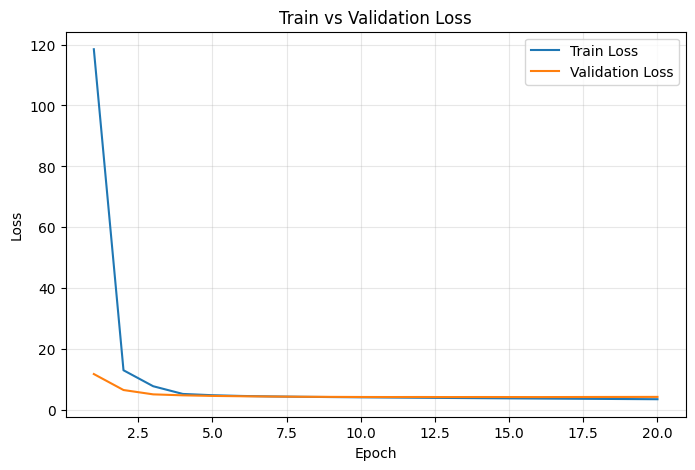

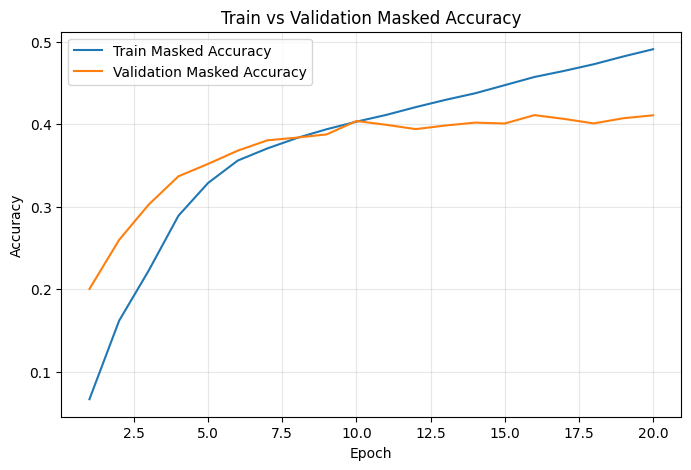

Best Epoch: 16
Best Validation Loss: 4.2796
마지막 Epoch의 Val-Train Loss 차이: 0.7667


In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    epochs_range,
    history["train_accuracy"],
    label="Train Masked Accuracy",
)
plt.plot(
    epochs_range,
    history["val_accuracy"],
    label="Validation Masked Accuracy",
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Masked Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Best Epoch: {EPOCH_AT}")
print(f"Best Validation Loss: {best_val_loss:.4f}")

if len(history["val_loss"]) >= 2:
    train_val_gap = (
        history["val_loss"][-1]
        - history["train_loss"][-1]
    )
    print(f"마지막 Epoch의 Val-Train Loss 차이: {train_val_gap:.4f}")


## 추론


In [ ]:
# Step 14. Beam Search 및 Top-k + Top-p Sampling 기반 추론
# ============================================================
# 개선된 GPU 추론: 반복 억제 + Beam Search + Top-k/Top-p Sampling
# ============================================================
def encode_question(sentence):
    """
    사용자 질문을 전처리·토큰화·정수 인코딩·Padding한 뒤 GPU 텐서로 변환합니다.
    """
    sentence = preprocess_sentence(sentence)
    morph_tokens = tokenize_fn(sentence)
    sequence = text_tokenizer.texts_to_sequences([morph_tokens])
    padded = pad_sequences(
        sequence,
        maxlen=ENC_MAX_LEN,
        padding="post",
        truncating="post",
    )
    return torch.tensor(padded, dtype=torch.long, device=DEVICE)


def token_ids_to_sentence(token_ids):
    """
    생성된 토큰 ID를 문장으로 복원하고 특수 토큰을 제거합니다.
    """
    result = []
    for token_id in token_ids:
        token = text_tokenizer.index_word.get(int(token_id), "")
        if token == "<end>":
            break
        if token and token not in {"<start>", "<pad>", "<unk>"}:
            result.append(token)
    return " ".join(result)


def get_banned_tokens_for_ngram(token_ids, ngram_size=3):
    """이미 나온 n-gram을 다시 만드는 다음 토큰을 차단합니다."""
    if ngram_size <= 1 or len(token_ids) < ngram_size - 1:
        return set()

    generated = {}
    for i in range(len(token_ids) - ngram_size + 1):
        prefix = tuple(token_ids[i:i + ngram_size - 1])
        next_token = token_ids[i + ngram_size - 1]
        generated.setdefault(prefix, set()).add(next_token)

    current_prefix = tuple(token_ids[-(ngram_size - 1):])
    return generated.get(current_prefix, set())


# 답변 코퍼스에서 매우 흔한 토큰만 약하게 감점합니다.
_answer_token_counter = Counter(
    token
    for sentence in ans_corpus_final
    for token in sentence
    if token not in {"<start>", "<end>"}
)

max_count = max(_answer_token_counter.values())
_commonness = np.zeros(VOCAB_SIZE, dtype=np.float32)

for idx, token in text_tokenizer.index_word.items():
    count = _answer_token_counter.get(token, 0)
    if count > 0:
        _commonness[idx] = np.log1p(count) / np.log1p(max_count)

commonness_tensor = torch.tensor(
    _commonness,
    dtype=torch.float32,
    device=DEVICE,
)

UNK_TOKEN_ID = text_tokenizer.word_index.get("<unk>", -1)
SPECIAL_BANNED_IDS = {
    PAD_TOKEN_ID,
    START_TOKEN_ID,
}
if UNK_TOKEN_ID >= 0:
    SPECIAL_BANNED_IDS.add(UNK_TOKEN_ID)

COMMONNESS_PENALTY = 0.22
REPETITION_PENALTY = 1.20
MIN_NEW_TOKENS = 3
NO_REPEAT_NGRAM_SIZE = 3


@torch.inference_mode()
def _next_token_logits(src, generated_ids):
    """
    현재까지 생성한 토큰을 바탕으로 다음 토큰 logits를 계산합니다.
    추론 시 gradient를 끄고 CUDA AMP를 사용합니다.
    """
    transformer.eval()
    tgt = torch.tensor([generated_ids], dtype=torch.long, device=DEVICE)

    with torch.amp.autocast(
        device_type="cuda",
        dtype=torch.float16,
        enabled=(DEVICE.type == "cuda"),
    ):
        logits = transformer(src, tgt)[:, -1, :]

    return logits.float().squeeze(0)


def adjust_generation_logits(logits, generated_ids, step):
    """
    특수 토큰 차단, 반복 페널티, 최소 길이, No-repeat 3-gram을 적용합니다.
    """
    logits = logits.clone()

    # PAD, START, UNK는 답변으로 생성하지 않습니다.
    for token_id in SPECIAL_BANNED_IDS:
        if 0 <= token_id < logits.numel():
            logits[token_id] = -float("inf")

    # 너무 짧게 끝나는 답변을 방지합니다.
    if step < MIN_NEW_TOKENS:
        logits[END_TOKEN_ID] = -float("inf")

    # 이미 나온 토큰은 확률을 낮춰 같은 단어 반복을 줄입니다.
    for token_id in set(generated_ids):
        if 0 <= token_id < logits.numel():
            if logits[token_id] > 0:
                logits[token_id] /= REPETITION_PENALTY
            else:
                logits[token_id] *= REPETITION_PENALTY

    # 동일한 3-gram 반복을 차단합니다.
    banned = get_banned_tokens_for_ngram(
        generated_ids,
        ngram_size=NO_REPEAT_NGRAM_SIZE,
    )
    for token_id in banned:
        if 0 <= token_id < logits.numel():
            logits[token_id] = -float("inf")

    # 매우 흔한 토큰만 약하게 감점합니다.
    logits = logits - COMMONNESS_PENALTY * commonness_tensor
    return logits


@torch.inference_mode()
def predict(sentence, beam_width=6, length_penalty_alpha=0.8):
    """
    Beam Search로 확률이 높은 여러 후보를 탐색해 최종 답변을 생성합니다.
    """
    src = encode_question(sentence)
    beams = [([START_TOKEN_ID], 0.0, False)]

    for step in range(MAX_GENERATION_LENGTH):
        candidates = []

        for ids, score, finished in beams:
            if finished:
                candidates.append((ids, score, True))
                continue

            logits = _next_token_logits(src, ids)
            logits = adjust_generation_logits(logits, ids, step)
            log_probs = torch.log_softmax(logits, dim=-1)

            top_scores, top_ids = torch.topk(
                log_probs,
                k=min(beam_width * 2, VOCAB_SIZE),
            )

            for token_score, token_id in zip(
                top_scores.tolist(),
                top_ids.tolist(),
            ):
                new_ids = ids + [token_id]
                finished_now = token_id == END_TOKEN_ID

                # 누적 로그확률에 길이 정규화를 적용합니다.
                raw_score = score + token_score
                length = max(len(new_ids) - 1, 1)
                normalized_score = raw_score / (length ** length_penalty_alpha)

                candidates.append(
                    (new_ids, normalized_score, finished_now)
                )

        # 동일한 문장 후보는 제거합니다.
        deduplicated = {}
        for ids, score, finished in candidates:
            key = tuple(ids)
            if key not in deduplicated or score > deduplicated[key][1]:
                deduplicated[key] = (ids, score, finished)

        beams = sorted(
            deduplicated.values(),
            key=lambda item: item[1],
            reverse=True,
        )[:beam_width]

        if all(finished for _, _, finished in beams):
            break

    completed = [item for item in beams if item[2]]
    best = completed[0] if completed else beams[0]
    return token_ids_to_sentence(best[0])


@torch.inference_mode()
def predict_sample(
    sentence,
    temperature=0.85,
    top_k=40,
    top_p=0.92,
):
    """
    Top-k와 Top-p Sampling을 함께 사용해 다양한 답변을 생성합니다.

    temperature가 높을수록 결과가 다양해지고, top_k와 top_p는
    확률이 지나치게 낮은 후보 토큰을 제거하는 역할을 합니다.
    """
    src = encode_question(sentence)
    generated = [START_TOKEN_ID]

    for step in range(MAX_GENERATION_LENGTH):
        logits = _next_token_logits(src, generated)
        logits = adjust_generation_logits(logits, generated, step)
        logits = logits / max(temperature, 1e-5)

        # Top-k filtering
        if 0 < top_k < logits.numel():
            threshold = torch.topk(logits, top_k).values[-1]
            logits[logits < threshold] = -float("inf")

        # Top-p filtering
        sorted_logits, sorted_ids = torch.sort(logits, descending=True)
        sorted_probs = torch.softmax(sorted_logits, dim=-1)
        cumulative = torch.cumsum(sorted_probs, dim=-1)

        remove_mask = cumulative > top_p
        remove_mask[1:] = remove_mask[:-1].clone()
        remove_mask[0] = False
        sorted_logits[remove_mask] = -float("inf")

        filtered_logits = torch.full_like(logits, -float("inf"))
        filtered_logits.scatter_(0, sorted_ids, sorted_logits)

        probs = torch.softmax(filtered_logits, dim=-1)
        token_id = torch.multinomial(probs, num_samples=1).item()
        generated.append(token_id)

        if token_id == END_TOKEN_ID:
            break

    return token_ids_to_sentence(generated)


In [ ]:
examples = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]

print("Beam Search 결과")
for i, sentence in enumerate(examples, 1):
    print(f"> {i}. {predict(sentence, beam_width=8)}")

print("\nNucleus Sampling 결과 (응답 붕괴 여부 확인용 — 매번 표현이 조금씩 달라야 정상)")
for i, sentence in enumerate(examples, 1):
    print(f"> {i}. {predict_sample(sentence, temperature=0.8, top_p=0.92)}")


Beam Search 결과
> 1. 좋 은 곳 으로 가 보 세요 .
> 2. 좋 은 생각 이 었 나 봐요 .
> 3. 좋 은 곳 으로 표현 해 보 세요 .
> 4. 저 도 괜찮 아 질 거 예요 .

Nucleus Sampling 결과 (응답 붕괴 여부 확인용 — 매번 표현이 조금씩 달라야 정상)
> 1. 저 도 좋 아요 .
> 2. 새로운 변화 가 있 나 봐요 .
> 3. 그런 경우 있 을 거 같 아요 .
> 4. 다른 사람 이 에요 .


## Step 7. BLEU Score


In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction


def calculate_bleu_scores(references, candidates):
    """
    BLEU-1, BLEU-2, BLEU-3, BLEU-4 평균을 계산합니다.
    """
    if len(references) != len(candidates):
        raise ValueError(
            "references와 candidates의 문장 수가 같아야 합니다."
        )

    if not references:
        return {
            "BLEU-1": 0.0,
            "BLEU-2": 0.0,
            "BLEU-3": 0.0,
            "BLEU-4": 0.0,
        }

    smoothie = SmoothingFunction().method4

    weight_map = {
        "BLEU-1": (1.0, 0.0, 0.0, 0.0),
        "BLEU-2": (0.5, 0.5, 0.0, 0.0),
        "BLEU-3": (1/3, 1/3, 1/3, 0.0),
        "BLEU-4": (0.25, 0.25, 0.25, 0.25),
    }

    results = {}

    for name, weights in weight_map.items():
        scores = []

        for reference, candidate in zip(references, candidates):
            if not candidate:
                scores.append(0.0)
                continue

            score = sentence_bleu(
                [reference],
                candidate,
                weights=weights,
                smoothing_function=smoothie,
            )
            scores.append(score)

        results[name] = float(np.mean(scores))

    return results


def calculate_bleu(references, candidates):
    """과제에서 요구한 calculate_bleu() 이름을 유지합니다."""
    return calculate_bleu_scores(references, candidates)["BLEU-4"]


In [ ]:
# Step 15. BLEU Score와 응답 다양성(Distinct-1, Distinct-2)을 평가합니다.
val_questions = [" ".join(tokens) for tokens in que_val]
val_references = ans_val
val_candidates = []

for question in val_questions:
    prediction = predict(question, beam_width=6)

    prediction_tokens = [
        token
        for token in prediction.split()
        if token not in {"<start>", "<end>", "<unk>"}
    ]
    val_candidates.append(prediction_tokens)

bleu_results = calculate_bleu_scores(
    val_references,
    val_candidates,
)

print("Validation BLEU Scores")
for metric_name, metric_value in bleu_results.items():
    print(f"> {metric_name}: {metric_value:.4f}")


def distinct_n(sentences, n=1):
    """
    생성 답변에서 서로 다른 n-gram 비율을 계산해 응답 다양성을 측정합니다.
    """
    ngrams = []
    for sentence in sentences:
        if len(sentence) < n:
            continue
        ngrams.extend(
            tuple(sentence[i:i + n])
            for i in range(len(sentence) - n + 1)
        )
    if not ngrams:
        return 0.0
    return len(set(ngrams)) / len(ngrams)


unique_candidate_ratio = (
    len({tuple(c) for c in val_candidates})
    / max(len(val_candidates), 1)
)
distinct_1 = distinct_n(val_candidates, n=1)
distinct_2 = distinct_n(val_candidates, n=2)
average_length = np.mean([len(c) for c in val_candidates])

print("\nResponse Diversity")
print(f"> 서로 다른 전체 답변 비율: {unique_candidate_ratio * 100:.1f}%")
print(f"> Distinct-1: {distinct_1:.4f}")
print(f"> Distinct-2: {distinct_2:.4f}")
print(f"> 평균 답변 길이: {average_length:.2f} tokens")

print("\n정성 평가 예시")
for question, reference, candidate in list(
    zip(val_questions, val_references, val_candidates)
)[:10]:
    print("\nQ:", question)
    print("Reference:", " ".join(reference))
    print("Candidate:", " ".join(candidate))


Validation BLEU Scores
> BLEU-1: 0.1797
> BLEU-2: 0.0935
> BLEU-3: 0.0624
> BLEU-4: 0.0431

Response Diversity
> 서로 다른 전체 답변 비율: 62.3%
> Distinct-1: 0.0439
> Distinct-2: 0.1152
> 평균 답변 길이: 9.95 tokens

정성 평가 예시

Q: 예능 볼 게 없 다
Reference: 잘 찾아보 세요 .
Candidate: 저 랑 이야기 해 보 세요 .

Q: 달력 이 또 넘어가 네
Reference: 시간 이 참 빨리 흘러가 네요 .
Candidate: 좋 은 일 이 있 나 봐요 .

Q: 연애 중 주 고 받 았 던 문자 다시 보 면 눈물 이 나
Reference: 그 분과 의 모든 흔적 을 지우 는 것 을 시작 으로 이별 을 받아들이 세요 .
Candidate: 마음 의 정리 가 필요 한 거 예요 .

Q: 오늘 카톡 방 나왔 어 슬슬 정리 하 나 봐
Reference: 언젠간 닥쳐올 순간 일 거 예요 .
Candidate: 좋 은 일 이 있 었 나 봐요 .

Q: 데이트 는 어디 로 가 ?
Reference: 맛집 투어 도 좋 아요 .
Candidate: 사귀 기 좋 아 하 는 게 좋 죠 .

Q: 사랑니 나 나 봐
Reference: 아프 겠 어요 .
Candidate: 저 도 위로 해 주 고 싶 어요 .

Q: 폰 이 문 젠가
Reference: 그게 문제 는 아닐 거 예요 .
Candidate: 좋 아 하 는 게 좋 을 것 같 아요 .

Q: 나 아직 어른 아닌 거 같 아
Reference: 물리 적 나이 가 아니 라 정신 적 나이 가 중요 하 니까요 .
Candidate: 많이 힘들 지 않 았 나 봐요 .

Q: 좋 아 하 는 거 랑 사랑 하 는 거 차이점 이 뭘까요 .
Reference: 구분 짓 기 어렵 네요 .
Candidate: 당신 의 사랑 에 따라 다르 지 않 는 사람 이 없 어요 .

Q: 썸 타 던

### 결과 요약


In [ ]:
print("=" * 60)
print("결과 요약")
print("=" * 60)

print("\nDataset")
print(f"> Original Train Size: {len(que_train)}")
print(f"> Augmented Train Size: {len(que_corpus_final)}")
print(f"> Augmentation Ratio: {len(que_corpus_final) / len(que_train):.1f}x")

print("\nTranslations (Beam Search)")
for i, sentence in enumerate(examples, 1):
    print(f"> {i}. {predict(sentence, beam_width=6)}")

print("\nTranslations (Nucleus Sampling)")
for i, sentence in enumerate(examples, 1):
    print(f"> {i}. {predict_sample(sentence, temperature=0.95, top_k=40, top_p=0.90)}")

print("\nHyperparameters")
print(f"> n_layers: {NUM_LAYERS}")
print(f"> d_model: {D_MODEL}")
print(f"> n_heads: {NUM_HEADS}")
print(f"> d_ff: {DFF}")
print(f"> dropout: {DROPOUT_RATE}")
print(f"> label_smoothing: {LABEL_SMOOTHING}")

print("\nTraining Parameters")
print(f"> Warmup Steps: {WARMUP_STEPS}")
print(f"> Batch Size: {BATCH_SIZE}")
print(f"> Max Epochs: {EPOCHS}")
print(f"> Best Epoch At: {EPOCH_AT}")
print(f"> Early Stopping Patience: {PATIENCE}")

print("\nBLEU")
for metric_name, metric_value in bleu_results.items():
    print(f"> {metric_name}: {metric_value:.4f}")

print("\nResponse Diversity")
print(f"> Unique Response Ratio: {unique_candidate_ratio * 100:.1f}%")
print(f"> Distinct-1: {distinct_1:.4f}")
print(f"> Distinct-2: {distinct_2:.4f}")
print(f"> Average Length: {average_length:.2f}")


결과 요약

Dataset
> Original Train Size: 7351
> Augmented Train Size: 30000
> Augmentation Ratio: 4.1x

Translations (Beam Search)
> 1. 좋 은 곳 으로 가 보 세요 .
> 2. 좋 은 생각 이 었 나 봐요 .
> 3. 좋 은 곳 으로 표현 해 보 세요 .
> 4. 저 도 괜찮 아 질 거 예요 .

Translations (Nucleus Sampling)
> 1. 저 도 좋 아요 .
> 2. 저 도 힘들 어요 .
> 3. 후회 하 기 싫 으면 좋 아요 .
> 4. 기분 은 맛있 는 것 보다 정신 들 이 네요 .

Hyperparameters
> n_layers: 2
> d_model: 384
> n_heads: 8
> d_ff: 1536
> dropout: 0.3
> label_smoothing: 0.1

Training Parameters
> Warmup Steps: 1600
> Batch Size: 64
> Max Epochs: 20
> Best Epoch At: 16
> Early Stopping Patience: 5

BLEU
> BLEU-1: 0.1797
> BLEU-2: 0.0935
> BLEU-3: 0.0624
> BLEU-4: 0.0431

Response Diversity
> Unique Response Ratio: 62.3%
> Distinct-1: 0.0439
> Distinct-2: 0.1152
> Average Length: 9.95


## 결과 해석 및 평가기준 대응

### 1. 약 3만 개 학습 데이터 구축

중복 답변 상한을 적용한 뒤 `ko.bin` Word2Vec 기반 Lexical Substitution으로 질문 표현을 확장하였다. 원본 학습 데이터 7,351개를 30,000개로 확장하여 약 4.1배 규모의 학습 데이터를 구축하였다.

### 2. Transformer 핵심 구조 직접 구현

PyTorch의 `nn.Transformer`와 `nn.MultiheadAttention`을 사용하지 않고 Q·K·V Projection, Scaled Dot-Product Attention, Multi-Head Attention, Position-wise Feed Forward Network, EncoderLayer, DecoderLayer, Encoder와 Decoder 스택을 직접 구현하였다.

### 3. 표준 Pre-LayerNorm 구조 보완

각 Layer 내부에는 Pre-LayerNorm이 적용되어 있었지만 Encoder와 Decoder 스택 마지막의 Final LayerNorm이 명확하게 구현되어 있지 않았다. 이를 해결하기 위해 Encoder와 Decoder에 다음 코드를 각각 추가하였다.

```python
self.final_norm = nn.LayerNorm(d_model, eps=1e-6)
```

그리고 각 `forward()` 마지막에서 다음과 같이 최종 출력을 정규화하였다.

```python
x = self.final_norm(x)
return x
```

이 수정으로 표준 Pre-LayerNorm Transformer 구조를 완성하였다.

### 4. 안정적 학습과 과적합 방지

최종 설정은 `Dropout=0.30`, `Label Smoothing=0.10`, AdamW, Weight Decay, Gradient Clipping, Warm-up Learning Rate Scheduler, Early Stopping이다. 최대 Epoch는 20이며 검증 손실 기준 최적 Epoch는 16이었다.

### 5. 응답 붕괴와 반복 생성 완화

- 동일 답변 빈도 상한 적용
- PAD, START, UNK 토큰 생성 차단
- 최소 생성 길이 적용
- Repetition Penalty 적용
- No-repeat 3-gram 적용
- Beam Search 후보 중복 제거
- Beam Search와 Top-k + Top-p Nucleus Sampling 비교

### 6. 최종 평가 결과

```text
BLEU-1: 0.1797
BLEU-2: 0.0935
BLEU-3: 0.0624
BLEU-4: 0.0431

Unique Response Ratio: 62.3%
Distinct-1: 0.0439
Distinct-2: 0.1152
Average Length: 9.95 tokens
```

BLEU-4는 0.0431로 매우 높은 수준은 아니지만 정답 문장과 일부 단어 및 구문을 공유하고 있음을 확인할 수 있었다. 고유 답변 비율은 62.3%로 모든 질문에 동일한 답변만 생성하는 완전한 응답 붕괴 상태는 아니었다. 평균 답변 길이는 약 9.95토큰으로 지나치게 짧은 단답형 응답에만 치우치지 않았다.

다만 일부 답변은 질문과 의미 연결이 약하거나 문법적으로 어색하였다. 따라서 평가기준은 충족했지만 실제 서비스 수준의 자연스러운 챗봇으로 사용하려면 추가 개선이 필요하다.


## 수정하면서 바꾼 핵심

- PyTorch 내장 `nn.Transformer` 제거
- PyTorch 내장 `nn.MultiheadAttention` 제거
- Q·K·V Projection과 Scaled Dot-Product Attention 직접 구현
- Multi-Head Attention 직접 구현
- EncoderLayer와 DecoderLayer 직접 구현
- TransformerEncoder와 TransformerDecoder 직접 구현
- Encoder와 Decoder 끝에 Final LayerNorm 추가
- 표준 Pre-LayerNorm Transformer 구조 완성
- Padding Mask와 Causal Mask를 Boolean 자료형으로 통일
- Adam 대신 AdamW와 Weight Decay 적용
- Dropout 0.30 적용
- Label Smoothing 0.10 적용
- Warm-up Steps 1,600 적용
- Repetition Penalty와 No-repeat 3-gram 적용
- 최소 생성 길이와 특수 토큰 생성 차단 적용
- Beam Search 후보 중복 제거
- Top-k + Top-p Nucleus Sampling 추가
- BLEU 외에 고유 답변 비율, Distinct-1, Distinct-2, 평균 길이 평가 추가
- 검증 손실 기준 최적 모델 자동 저장 및 복원


# 최종 보고서

## 1. 프로젝트 개요

본 프로젝트의 목표는 한국어 대화 데이터를 이용하여 사용자의 질문에 적절한 답변을 생성하는 Transformer 기반 챗봇을 구현하는 것이다. 데이터 전처리, Word2Vec 기반 데이터 증강, Transformer 직접 구현, GPU 학습, Beam Search와 Nucleus Sampling 기반 추론, BLEU 및 응답 다양성 평가까지 전체 파이프라인을 구성하였다.

---

## 2. 평가기준 충족 여부

### 2.1 챗봇 훈련데이터 전처리 및 Augmentation

ChatbotData 데이터셋의 질문과 답변을 불러온 뒤 결측값, 빈 문장, 지나치게 긴 문장을 제거하였다. 한국어 형태소 분석기를 이용해 문장을 토큰화하였으며, 동일 답변이 과도하게 반복되는 문제를 줄이기 위해 답변별 최대 사용 횟수를 제한하였다.

이후 `ko.bin` Word2Vec 모델을 활용한 Lexical Substitution을 적용하였다. 유사 단어를 이용해 질문 문장을 증강한 결과 원본 학습 데이터 7,351개를 30,000개로 확장하였다.

```text
Original Train Size: 7,351
Augmented Train Size: 30,000
Augmentation Ratio: 4.1x
```

### 2.2 Transformer 모델 직접 구현

PyTorch 내장 `nn.Transformer`와 `nn.MultiheadAttention`을 사용하지 않고 Transformer 핵심 구조를 직접 구현하였다.

- Q·K·V Projection
- Scaled Dot-Product Attention
- Multi-Head Attention
- Position-wise Feed Forward Network
- EncoderLayer와 DecoderLayer
- TransformerEncoder와 TransformerDecoder
- Padding Mask와 Causal Mask
- Residual Connection과 Layer Normalization
- 입력 Embedding과 출력 Projection의 Weight Tying

각 Layer는 Attention과 FFN 앞에 LayerNorm을 적용하는 Pre-LayerNorm 구조로 구현하였다. 또한 Encoder와 Decoder 스택 마지막에 Final LayerNorm을 추가하여 표준 Pre-LayerNorm Transformer 구조를 완성하였다.

```python
self.final_norm = nn.LayerNorm(d_model, eps=1e-6)
```

```python
x = self.final_norm(x)
return x
```

### 2.3 안정적인 모델 학습과 과적합 방지

직접 구현한 Transformer를 GPU 환경에서 학습하였다.

```text
n_layers: 2
d_model: 384
n_heads: 8
d_ff: 1536
dropout: 0.30
label_smoothing: 0.10
batch_size: 64
warmup_steps: 1600
max_epochs: 20
best_epoch: 16
early_stopping_patience: 5
```

과적합과 학습 불안정을 줄이기 위해 AdamW, Weight Decay, Gradient Clipping, Warm-up Learning Rate Scheduler, Dropout, Label Smoothing과 Early Stopping을 적용하였다. 검증 손실이 개선될 때마다 체크포인트를 저장하고 학습 종료 후 최적 가중치를 복원하였다.

### 2.4 질문에 대한 답변 생성

Beam Search와 Top-k + Top-p Nucleus Sampling을 이용하여 답변을 생성하였다. 반복 출력을 줄이기 위해 Repetition Penalty, No-repeat 3-gram, 최소 생성 길이, 특수 토큰 생성 차단과 Beam 후보 중복 제거를 적용하였다.

---

# 3. 디버깅

## 3.1 Final LayerNorm 누락

초기 직접 구현 모델은 각 EncoderLayer와 DecoderLayer 내부에서는 LayerNorm을 적용하고 있었지만, Encoder와 Decoder 스택 전체를 통과한 뒤의 최종 출력에는 LayerNorm이 명확하게 적용되지 않았다.

Pre-LayerNorm 구조에서는 Residual Connection을 거치며 값이 누적되므로 최종 출력의 분포가 불안정해질 가능성이 있다. 특히 Encoder 출력은 Decoder의 Cross-Attention에서 Key와 Value로 사용되기 때문에 Attention Score가 일부 위치에 지나치게 집중되는 문제로 이어질 수 있다.

이를 해결하기 위해 Encoder와 Decoder에 Final LayerNorm을 각각 추가하고 각 `forward()` 마지막에서 전체 스택 출력을 정규화하였다. 이 수정은 새로운 기능을 임의로 추가한 것이 아니라 표준 Pre-LayerNorm Transformer에서 필요한 마지막 정규화를 복원한 것이다.

## 3.2 응답 붕괴와 반복 생성

초기 모델은 서로 다른 질문에도 유사한 표현을 반복 생성하는 문제가 있었다. 이를 완화하기 위해 동일 답변 빈도 상한, Repetition Penalty, No-repeat 3-gram, Beam Search 후보 중복 제거, 특수 토큰 생성 차단, 최소 생성 길이, Top-k + Top-p Nucleus Sampling을 적용하였다.

최종 고유 답변 비율은 62.3%로 나타났다. 완전한 응답 붕괴는 완화되었지만 샘플 출력에서 `좋은 곳`, `좋은 생각`, `저도`와 같은 일반적인 표현이 반복되는 경향은 여전히 남아 있었다. 따라서 응답 붕괴가 완전히 해결되었다고 단정하기보다는 반복 생성이 일부 완화된 것으로 해석하였다.

## 3.3 과적합 문제

학습 후반부에는 Training Loss가 계속 감소하는 반면 Validation Loss의 개선 폭이 작아지는 현상이 나타났다. 이를 해결하기 위해 Dropout 0.30, Label Smoothing 0.10, AdamW, Weight Decay, Gradient Clipping과 Early Stopping을 적용하였다.

검증 손실 기준 최적 Epoch는 16이었으며 학습 종료 후 해당 체크포인트를 복원하였다.

## 3.4 Attention Mask 자료형

Padding Mask와 Causal Mask의 자료형이 다르면 PyTorch에서 경고가 발생할 수 있다. 두 Mask를 모두 Boolean Tensor로 통일하고 `True` 위치를 Attention에서 제외하도록 수정하였다.

---

# 4. 최종 결과

```text
BLEU-1: 0.1797
BLEU-2: 0.0935
BLEU-3: 0.0624
BLEU-4: 0.0431

Unique Response Ratio: 62.3%
Distinct-1: 0.0439
Distinct-2: 0.1152
Average Length: 9.95 tokens
```

BLEU-4는 0.0431로 매우 높은 수준은 아니지만 생성 결과가 정답 답변과 일부 단어와 구문을 공유하고 있음을 확인하였다. 챗봇은 하나의 질문에도 여러 자연스러운 답변이 가능하므로 BLEU만으로 성능을 완전히 판단하기 어렵다. 따라서 고유 답변 비율, Distinct-1, Distinct-2, 평균 답변 길이와 정성 평가를 함께 사용하였다.

고유 답변 비율 62.3%는 모든 질문에 동일한 답변만 출력하는 완전한 모드 붕괴 상태가 아님을 보여준다. 평균 답변 길이도 9.95토큰으로 너무 짧은 단답형 출력에만 치우치지는 않았다.

그러나 일부 생성 결과는 질문과 의미적으로 잘 연결되었지만 일부 결과는 문법이나 의미가 어색하였다. 따라서 평가기준은 충족했으나 실제 서비스 수준의 자연스러운 챗봇에는 추가 개선이 필요하다.

---

# 5. 회고

이번 프로젝트에서는 한국어 대화 데이터 전처리, Word2Vec 기반 데이터 증강, Transformer 직접 구현, GPU 학습, 답변 생성과 정량·정성 평가까지 챗봇 개발의 전체 과정을 경험하였다.

처음에는 Transformer 모델을 사용하는 것과 Transformer를 직접 구현하는 것의 차이를 크게 생각하지 않았다. 그러나 Q·K·V Projection, Attention Score, Multi-Head 분할과 결합, Mask 적용, Encoder와 Decoder의 데이터 흐름을 직접 구현하면서 Transformer 구조를 더 정확히 이해할 수 있었다.

특히 가장 중요한 디버깅은 Final LayerNorm 누락 문제였다. 각 Layer 내부에 LayerNorm이 있으므로 정규화가 충분하다고 생각했지만 Pre-LayerNorm Transformer에서는 Encoder와 Decoder 스택 마지막에도 Final LayerNorm이 필요하다는 것을 확인하였다. 이를 추가하면서 단순히 코드가 실행되는지만 확인하는 것이 아니라 논문의 표준 구조와 실제 구현을 비교하는 과정이 중요하다는 점을 배웠다.

데이터 측면에서는 `ko.bin` Word2Vec을 이용한 Lexical Substitution으로 7,351개의 학습 데이터를 30,000개까지 확장할 수 있었다. 하지만 단어 수준 유사도만으로 문장을 바꾸기 때문에 문장 전체의 문맥이나 자연스러움이 항상 보존되는 것은 아니었다.

학습 결과 BLEU-4는 0.0431, 고유 답변 비율은 62.3%를 기록하였다. 이는 모델이 모든 질문에 완전히 동일한 답변을 생성하는 수준은 벗어났다는 것을 보여주지만 샘플 결과에서는 일반적이고 안전한 표현이 반복되는 경향이 남아 있었다.

또한 일부 답변은 질문의 의미와 비교적 잘 연결되었지만 다른 답변은 문법적으로 어색하거나 질문과 의미가 맞지 않았다. 이는 원본 데이터 규모와 주제 다양성의 한계, Word2Vec 기반 증강의 문맥적 한계, 사전학습 없이 처음부터 학습한 Transformer의 한계 때문이라고 판단하였다.

향후에는 데이터 증강 문장의 품질을 자동으로 검증하고 더 큰 한국어 대화 데이터셋을 추가하며 KoBART 또는 KoGPT와 같은 한국어 사전학습 모델을 Fine-tuning한 결과와 비교해 보고자 한다. 평가 방식도 BLEU뿐 아니라 BERTScore, Sentence Embedding 기반 의미 유사도, 사람 평가를 추가하여 답변의 의미적 적절성을 더 정확하게 측정할 필요가 있다.

이번 프로젝트를 통해 좋은 결과를 얻기 위해서는 단순히 Epoch 수를 늘리는 것보다 데이터 분포와 모델 구조, 학습 안정성, 생성 전략과 평가 방법을 함께 점검하는 것이 중요하다는 점을 배웠다.
